In [ ]:
# Install a pip comtradeapicall package in the current Jupyter kernel
import sys
!"{sys.executable}" -m pip install --upgrade comtradeapicall

In [ ]:
# Install a pip pandas package in the current Jupyter kernel
!"{sys.executable}" -m pip install pandas

In [ ]:
# Install a pip matplotlib package in the current Jupyter kernel
!"{sys.executable}" -m pip install matplotlib

In [ ]:
# Install a pip seaborn package in the current Jupyter kernel
!"{sys.executable}" -m pip install seaborn

In [ ]:
# Install a pip requests package in the current Jupyter kernel
!"{sys.executable}" -m pip install requests

In [ ]:
# Install a pip plotly package in the current Jupyter kernel
!"{sys.executable}" -m pip install plotly
!"{sys.executable}" -m pip install nbformat

In [7]:
import comtradeapicall
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.colors as pc

In [8]:
# use .env to store the subscription key
from dotenv import load_dotenv
import os

load_dotenv()
# comtrade api subscription key (from comtradedeveloper.un.org)
subscription_key = os.getenv("SUBSCRIPTION_KEY")
directory = '<OUTPUT DIR>'  # output directory for downloaded files

API

In [9]:
def fetch_trade_data(
    subscription_key,
    typeCode,
    freqCode,
    period,
    reporterCode,
    cmdCode,
    flowCode,
    partnerCode
):
    df = comtradeapicall.getTradeMatrixGroup(
        subscription_key,
        typeCode=typeCode,
        freqCode=freqCode,
        period=period,
        reporterCode=reporterCode,
        cmdCode=cmdCode,
        flowCode=flowCode,
        partnerCode=partnerCode
    )

    if df is None or df.empty:
        raise ValueError("No data returned from API")

    return df

Process data

In [ ]:
def process_trade_data(df):
    df = df.copy()
    df["trade_billions"] = df["primaryValue"] / 1e9
    df['period'] = df['period'].astype(str)

    # Define columns to keep
    columns_to_keep = [
        'period', 'reporterDesc', 'reporterCode', 'partnerDesc', 'partnerCode',
        'cmdDesc', 'cmdCode', 'flowCode', 'primaryValue', 'trade_billions'
    ]

    # Filter only if columns exist in the returned API data
    existing_cols = [c for c in columns_to_keep if c in df.columns]
    df_clean = df[existing_cols].copy()

    # Grouping logic
    group_cols = ['period', 'reporterDesc', 'partnerDesc', 'cmdDesc']
    df_grouped = df_clean.groupby(group_cols, as_index=False)[
        ['primaryValue', 'trade_billions']].sum()

    return df_grouped, df_clean

Pivot

In [ ]:
def pivot_trade(df, index_cols=None, value_col="trade_billions", aggfunc="sum"):
    df = df.copy()

    # Default columns if the user doesn't provide any
    if index_cols is None:
        index_cols = ['period', 'reporterDesc',
                      'partnerDesc', 'cmdDesc', 'flowCode']

    if value_col == "trade_billions" and "trade_billions" not in df.columns:
        df["trade_billions"] = df["primaryValue"] / 1e9

    pivot_df = df.pivot_table(
        index=index_cols,
        values=value_col,
        aggfunc=aggfunc
    ).reset_index()

    return pivot_df

Plot data

In [ ]:

def plot_trade_data_over_time(df_grouped, cmdCode):

    plt.figure(figsize=(10, 6))

    plt.plot(
        df_grouped["period"].astype(str),
        df_grouped["trade_billions"],
        marker="o",
        linewidth=2
    )

    plt.title(f"Grouped Trade Flow ({cmdCode})", fontsize=14)
    plt.xlabel("Period")
    plt.ylabel("Trade Value (Billions USD)")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Heatmap
def plot_trade_heatmap(df, index_col="partnerDesc", column_col="period", value_col="trade_billions"):
    # Pivot using the columns we know exist
    pivot = df.pivot_table(
        index=index_col, columns=column_col, values=value_col, aggfunc="sum")

    plt.figure(figsize=(12, 8))
    # annot=True if you want numbers in cells
    sns.heatmap(pivot, cmap="Blues", annot=False)
    plt.title(f"Trade Intensity by {index_col}")
    plt.tight_layout()
    plt.show()

# BAR CHART


def plot_comtrade_data(df):

    # Validation: Ensure the DataFrame has data
    if df is None or df.empty:
        print("No data available to plot.")
        return

    sns.set_style("whitegrid")

    # Create the catplot

    g = sns.catplot(
        data=df, kind="bar",
        x="period", y="trade_billions", hue="cmdDesc",
        col="reporterDesc", palette="viridis",
        height=5, aspect=1, col_wrap=2, legend=True, sharex=False
    )

    # Legend Positioning (Bottom Center)
    sns.move_legend(
        g, "upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=2,
        title="Commodity Description",
        frameon=True
    )

    g.fig.tight_layout()
    g.fig.subplots_adjust(bottom=0.2, top=0.88)

    try:
        # Use .unique() to handle cases where there might be multiple partners
        partners = df['partnerDesc'].unique()
        partner_label = partners[0] if len(
            partners) == 1 else "Various Partners"
    except (KeyError, IndexError):
        partner_label = "Unknown Partner"

    g.fig.suptitle(
        f'Trade Analysis: {partner_label}\nSITC 2-Digit Analysis',
        fontsize=16,
        weight='bold',
        y=0.98
    )

    g.set_axis_labels("Year", "Trade Value (Billions USD)")
    g.set_titles("{col_name}", weight="bold")

    plt.show()

# LINE PLOT


def plot_trade_trends(
    df,
    x_col="period",
    y_col="trade_billions",
    hue_col="partnerDesc",
    title="Trade Trends Over Time",
    xlabel=None,
    ylabel="Trade Value (Billions USD)",
    figsize=(10, 6),
    palette="tab10",
    marker="o",
    linewidth=2,
    style="whitegrid"
):
    # Validation
    if df is None or df.empty:
        print("No data available to plot.")
        return

    required_cols = [x_col, y_col, hue_col]

    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print(f"Missing columns: {missing_cols}")
        return

    # Styling
    sns.set_style(style)

    # Figure
    plt.figure(figsize=figsize)

    # Plot
    sns.lineplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,
        marker=marker,
        linewidth=linewidth,
        palette=palette
    )

    # Labels and title
    plt.title(title, fontsize=14, weight="bold")

    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(ylabel)

    # Improve x-axis formatting
    plt.xticks(rotation=0)

    # Legend
    plt.legend(title=hue_col)

    # Layout
    plt.tight_layout()

    # Show plot
    plt.show()

# SANKEY


def plot_sankey(df, source, target, value, title):

    df = df.copy()

    # Clean strings
    df[source] = df[source].astype(str).str.strip()
    df[target] = df[target].astype(str).str.strip()

    # Aggregate
    s = df.groupby([source, target], as_index=False)[value].sum()

    nodes = pd.Index(pd.concat([s[source], s[target]]).unique())
    mapping = {k: v for v, k in enumerate(nodes)}

    s["s"] = s[source].map(mapping)
    s["t"] = s[target].map(mapping)

    colors = pc.qualitative.Set3

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            label=list(nodes),
            color=[colors[i % len(colors)] for i in range(len(nodes))]
        ),
        link=dict(
            source=s["s"],
            target=s["t"],
            value=s[value],
            color="rgba(100,150,200,0.4)"
        )
    )])

    fig.update_layout(
        title=title,
        font_size=12
    )

    fig.show()

Save data

In [14]:
def save_trade_data(df_grouped, directory, output_csv="grouped_trade_matrix_analysis.csv"):
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")

    file_path = os.path.join(directory, output_csv)

    df_grouped.to_csv(output_csv, index=False)
    print(f"Data successfully saved to: {file_path}")

Input parameters

Scenario: Multiple reporters and single partner

**Japan + China vs Germany, USA export of Power generating machinery, other than electric to the World in 2023 and 2024

   period reporterDesc partnerDesc  \
0  (2023)  China+Japan       World   
1  (2023)      Germany       World   
2  (2023)          USA       World   
3  (2024)  China+Japan       World   
4  (2024)      Germany       World   

                                             cmdDesc  primaryValue  \
0  Steam or other vapour-generating boilers, supe...  2.006134e+09   
1  Steam or other vapour-generating boilers, supe...  3.157505e+08   
2  Steam or other vapour-generating boilers, supe...  2.723697e+08   
3  Steam or other vapour-generating boilers, supe...  1.585242e+09   
4  Steam or other vapour-generating boilers, supe...  3.014836e+08   

   trade_billions  
0        2.006134  
1        0.315751  
2        0.272370  
3        1.585242  
4        0.301484  
  reporterDesc partnerDesc                                            cmdDesc  \
0  China+Japan       World  Steam or other vapour-generating boilers, supe...   
1      Germany       World  Steam or other vapour-generating boilers

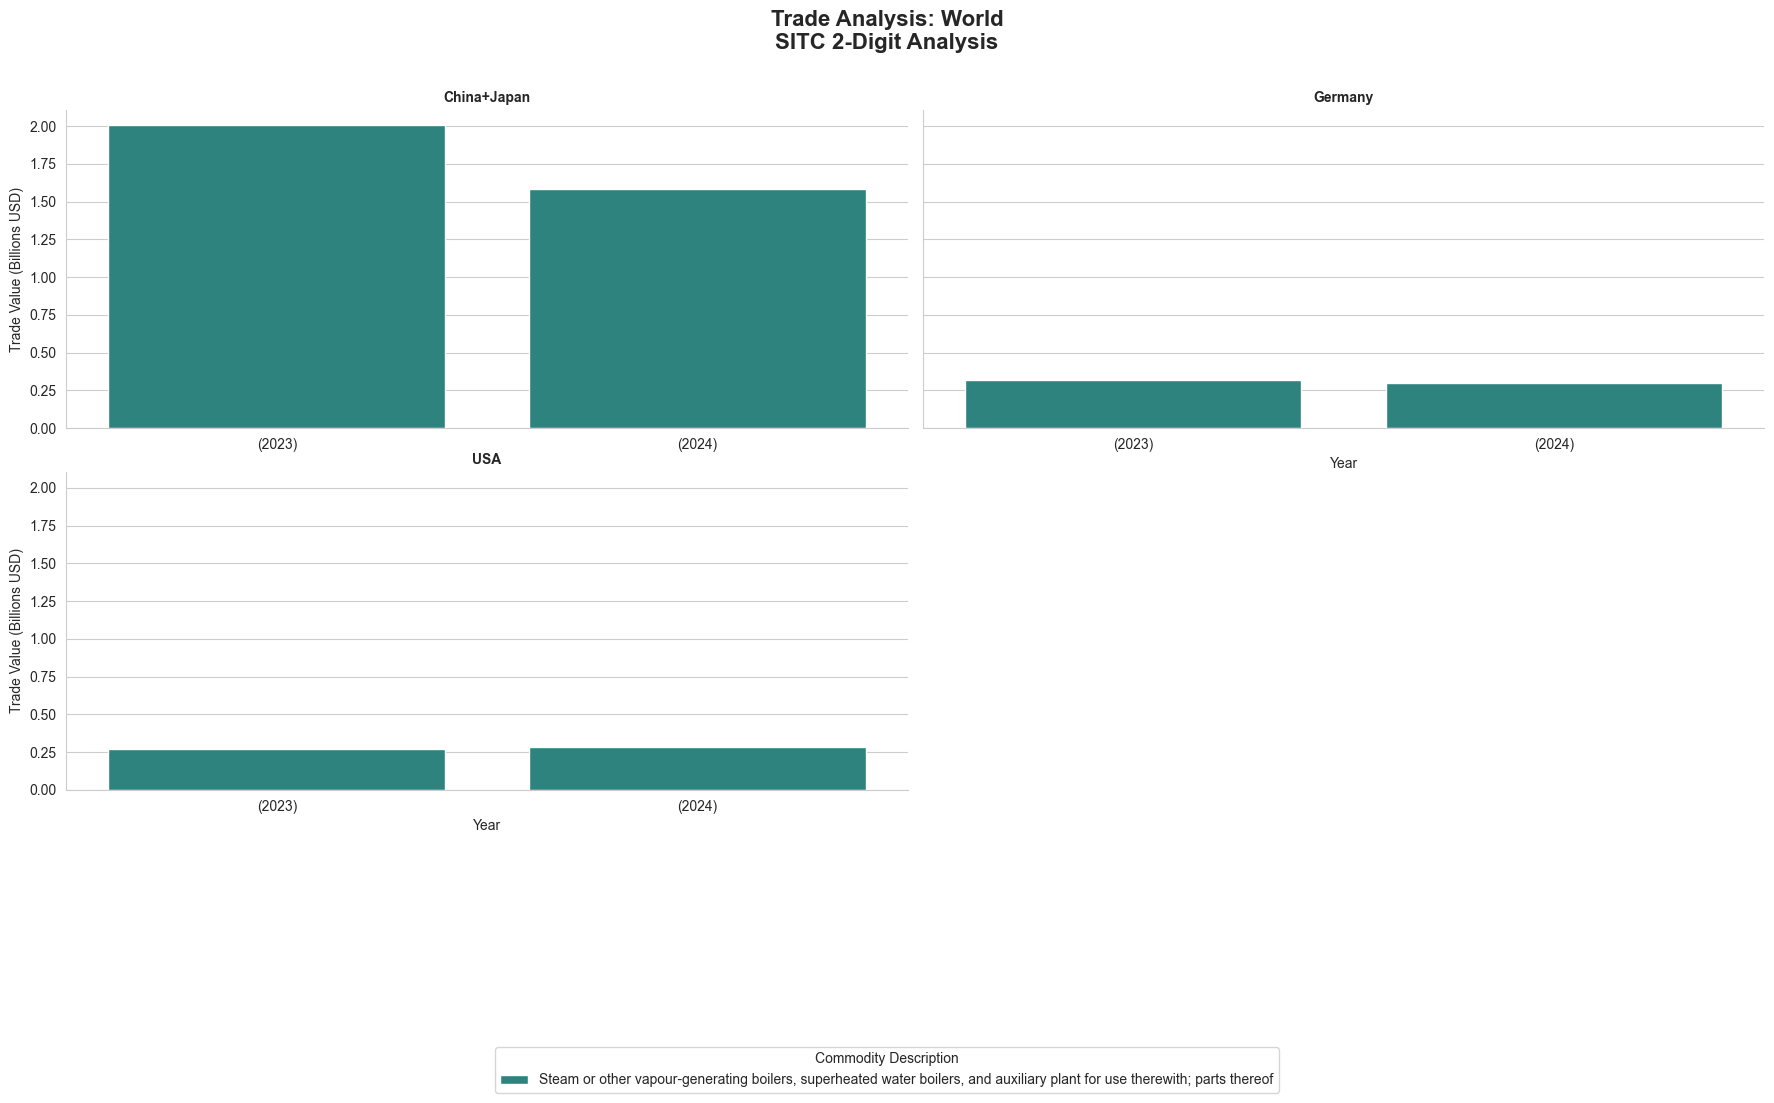

In [ ]:
# Scenario: Multiple reporters and single partner
# Japan + China vs Germany, USA export of Power generating machinery, other than electric to the World in 2023 and 2024
typeCode = 'C'  # commodity
freqCode = 'A'  # annual

# Grouping logic:
# +  → combines countries into one group
# ,  → runs multiple queries in one request

# Country/group codes are based on:
# https://comtradeapi.un.org/files/v1/app/reference/country_groups.json

reporterCode = '392+156, 276, 842'  # Japan + China, Germany, United States
partnerCode = '0'  # World

period = '2023, 2024'

cmdCode = '711'  # Power generating machinery, other than electric
flowCode = 'X'  # 'X'-Export ; 'M'-Import


# call API
df = fetch_trade_data(
    subscription_key,
    typeCode,
    freqCode,
    period,
    reporterCode,
    cmdCode,
    flowCode,
    partnerCode
)
df_grouped, df_clean = process_trade_data(df)
print(df_grouped.head())

df_pivot = pivot_trade(df_clean, index_cols=['reporterDesc', 'partnerDesc', 'cmdDesc'],
                       value_col="trade_billions")
print(df_pivot.head())


# Plot
plot_sankey(
    df=df_grouped,
    source="reporterDesc",
    target="partnerDesc",
    value="trade_billions",
    title="Global Power generating machinery, other than electric Exports (2023 and 2024)"
)

plot_comtrade_data(df_grouped)

Scenario: Single reporter and multiple partners

**USA import of Mineral fuels, lubricants and related materials from China, Japan and OPEC in 2022+2023 and 2024

        period reporterDesc partnerDesc  \
0  (2022+2023)          USA       China   
1  (2022+2023)          USA       Japan   
2  (2022+2023)          USA        OPEC   
3       (2024)          USA       China   
4       (2024)          USA       Japan   

                                           cmdDesc  primaryValue  \
0  Mineral fuels, lubricants and related materials  4.862999e+08   
1  Mineral fuels, lubricants and related materials  1.971621e+09   
2  Mineral fuels, lubricants and related materials  8.702311e+10   
3  Mineral fuels, lubricants and related materials  4.470194e+08   
4  Mineral fuels, lubricants and related materials  5.319994e+08   

   trade_billions  
0        0.486300  
1        1.971621  
2       87.023110  
3        0.447019  
4        0.531999  
  reporterDesc partnerDesc                                          cmdDesc  \
0          USA       China  Mineral fuels, lubricants and related materials   
1          USA       Japan  Mineral fuels, lubricants 

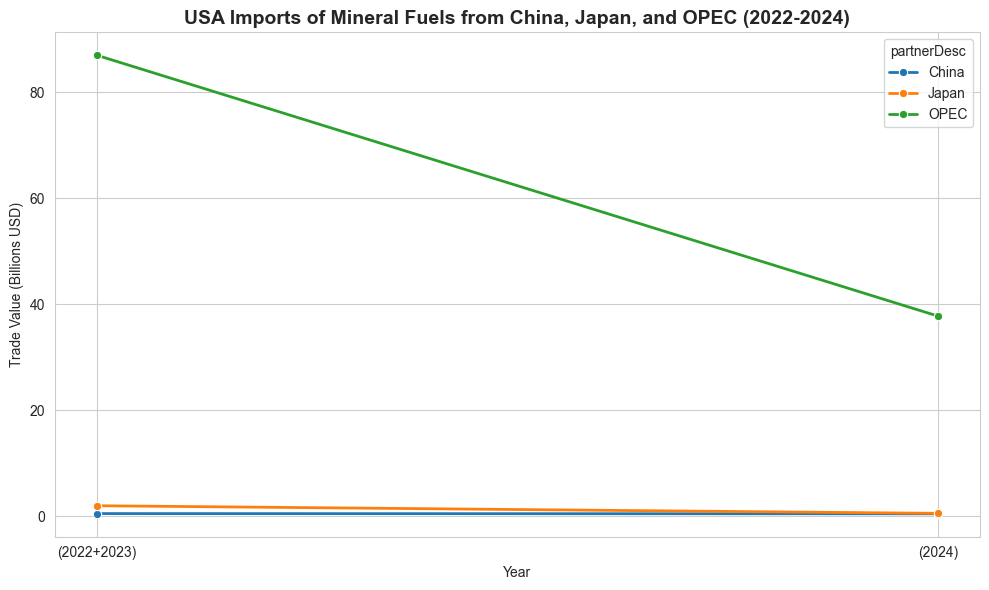

In [ ]:
# Scenario: Single reporter and multiple partners
# USA import of Mineral fuels, lubricants and related materials from China, Japan and OPEC in 2022+2023 and 2024

typeCode = 'C'  # commodity
freqCode = 'A'  # annual

# Grouping logic:
# +  → combines countries into one group
# ,  → runs multiple queries in one request

# Country/group codes are based on:
# https://comtradeapi.un.org/files/v1/app/reference/country_groups.json

reporterCode = '842'  # USA
partnerCode = '156, 392, OPEC'  # China, Japan, OPEC

period = '2022+2023, 2024'

cmdCode = '3'  # Mineral fuels, lubricants and related materials
flowCode = 'M'  # 'X'-Export ; 'M'-Import

# call API
df = fetch_trade_data(
    subscription_key,
    typeCode,
    freqCode,
    period,
    reporterCode,
    cmdCode,
    flowCode,
    partnerCode
)
df_grouped, df_clean = process_trade_data(df)
print(df_grouped.head())

df_pivot = pivot_trade(df_clean, index_cols=['reporterDesc', 'partnerDesc', 'cmdDesc'],
                       value_col="trade_billions")
print(df_pivot.head())

# Plot
plot_trade_trends(
    df=df_grouped,
    title="USA Imports of Mineral Fuels from China, Japan, and OPEC (2022-2024)",
    xlabel="Year"
)

plot_sankey(
    df=df_grouped,
    source="partnerDesc",
    target="reporterDesc",
    value="trade_billions",
    title="USA Imports of Mineral Fuels from China, Japan, and OPEC (2022-2024)"
)

Scenario: Multiple Reporters, Partners, and Commodities

**ECOWAS and COMESA Exports of Fertilizers and Iron and Steel to Brazil, India, China, and South Africa (2022, 2023)

   period reporterDesc                partnerDesc  \
0  (2022)       COMESA  Brazil+China+South Africa   
1  (2022)       COMESA  Brazil+China+South Africa   
2  (2022)       ECOWAS  Brazil+China+South Africa   
3  (2022)       ECOWAS  Brazil+China+South Africa   
4  (2023)       COMESA  Brazil+China+South Africa   

                                             cmdDesc  primaryValue  \
0  Crude fertilizers, other than those of Divisio...  2.323550e+08   
1                                     Iron and steel  2.890867e+08   
2  Crude fertilizers, other than those of Divisio...  1.319572e+07   
3                                     Iron and steel  1.291253e+07   
4  Crude fertilizers, other than those of Divisio...  8.264476e+08   

   trade_billions  
0        0.232355  
1        0.289087  
2        0.013196  
3        0.012913  
4        0.826448  
  reporterDesc                partnerDesc  \
0       COMESA  Brazil+China+South Africa   
1       COMESA  Brazil+China+South Africa   
2    

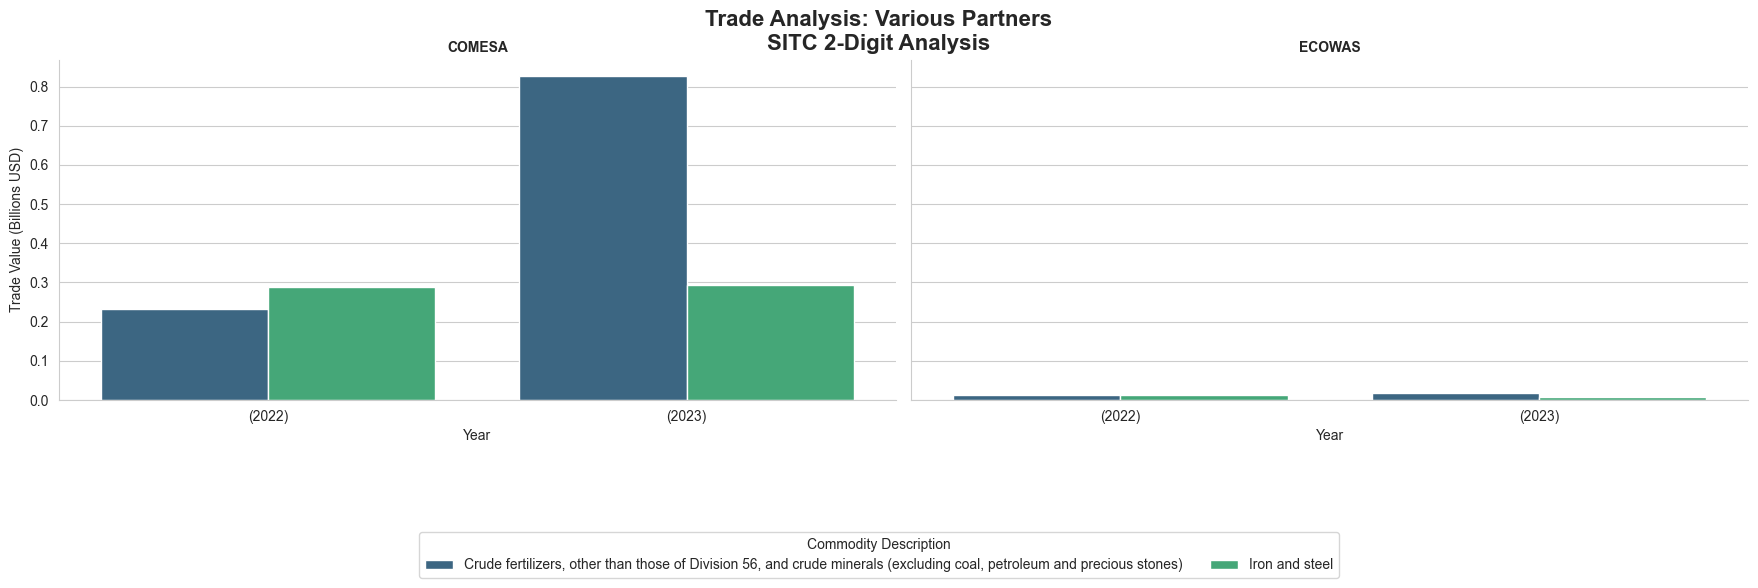

In [ ]:
# Scenario: Multiple Reporters, Partners, and Commodities
# ECOWAS and COMESA Exports of Fertilizers and Iron and Steel to Brazil, India, China, and South Africa (2022, 2023)

# variables
typeCode = 'C'  # commodity
freqCode = 'A'  # annual

# Grouping logic:
# +  → combines countries into one group
# ,  → runs multiple queries in one request

# Country/group codes are based on:
# https://comtradeapi.un.org/files/v1/app/reference/country_groups.json

# Economic Community of West African States vs. Common Market for Eastern and Southern Africa
reporterCode = 'ECOWAS, COMESA'
partnerCode = '76+356+156+710'  # Brazil+India+China+South Africa

period = '2022, 2023'

# 2-digit SITC commodity code
cmdCode = '27, 67'  # Fertilizers (27) and Iron and steel (67)
flowCode = 'X'  # 'X'-Export ; 'M'-Import

# call API
df = fetch_trade_data(
    subscription_key,
    typeCode,
    freqCode,
    period,
    reporterCode,
    cmdCode,
    flowCode,
    partnerCode
)
df_grouped, df_clean = process_trade_data(df)
print(df_grouped.head())

df_pivot = pivot_trade(df_clean, index_cols=['reporterDesc', 'partnerDesc', 'cmdDesc'],
                       value_col="trade_billions")
print(df_pivot.head())

# Plot
plot_comtrade_data(df_clean)

plot_sankey(
    df=df_grouped,
    source="reporterDesc",
    target="partnerDesc",
    value="trade_billions",
    title="ECOWAS and COMESA Exports of Fertilizers and Iron and Steel to Brazil, India, China, and South Africa (2022, 2023)"
)

**APEC, Germany and Japan Exports of Road vehicles and Other transport equipment to USA, Australia, UAE (2022-2024)

   period reporterDesc           partnerDesc  \
0  (2022)         APEC             Australia   
1  (2022)         APEC             Australia   
2  (2022)         APEC                   USA   
3  (2022)         APEC                   USA   
4  (2022)         APEC  United Arab Emirates   

                                          cmdDesc  primaryValue  \
0                       Other transport equipment  2.664116e+09   
1  Road vehicles (including air-cushion vehicles)  2.777828e+10   
2                       Other transport equipment  1.472248e+10   
3  Road vehicles (including air-cushion vehicles)  2.497115e+11   
4                       Other transport equipment  1.133787e+09   

   trade_billions  
0        2.664116  
1       27.778281  
2       14.722482  
3      249.711488  
4        1.133787  
  reporterDesc           partnerDesc  \
0         APEC             Australia   
1         APEC             Australia   
2         APEC                   USA   
3         APEC              

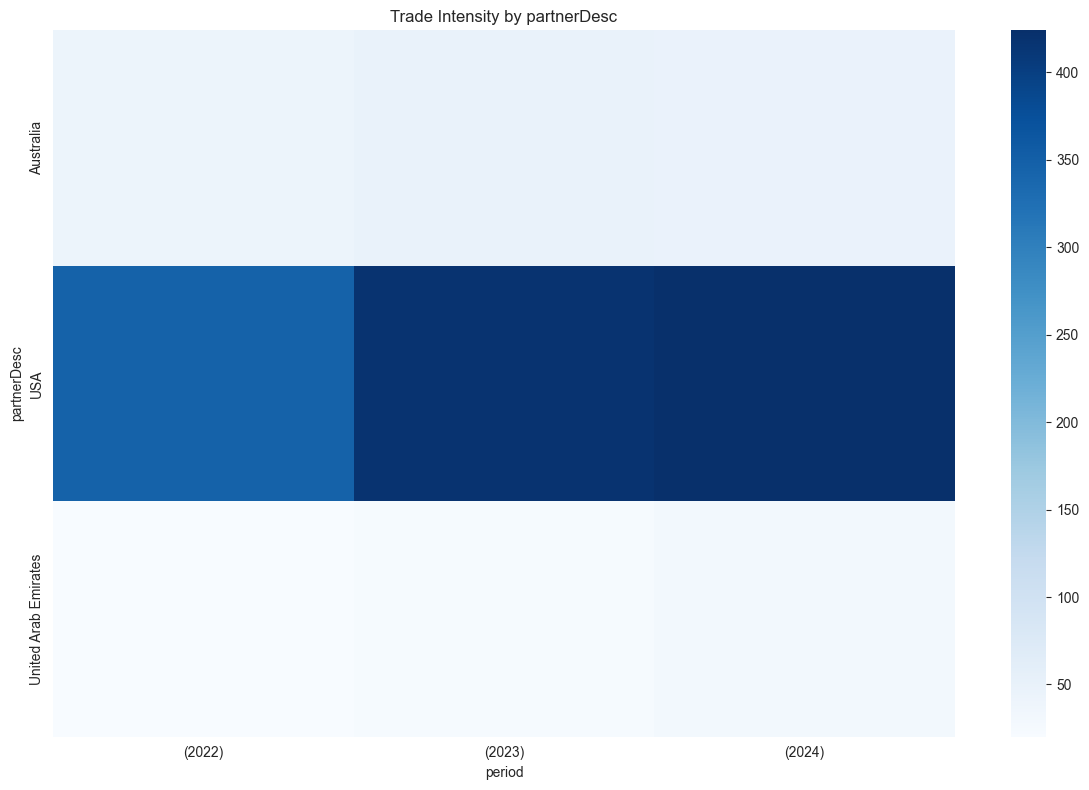

In [ ]:
# Scenario: Multiple Reporters, Partners, and Commodities
# APEC, Germany and Japan Exports of Road vehicles and Other transport equipment to USA, Australia, UAE (2022-2024)

# variables
typeCode = 'C'  # commodity
freqCode = 'A'  # annual

# Grouping logic:
# +  → combines countries into one group
# ,  → runs multiple queries in one request

# Country/group codes are based on:
# https://comtradeapi.un.org/files/v1/app/reference/country_groups.json

reporterCode = 'APEC, 276, 392'  # APEC, Germany, Japan
partnerCode = '842, 36, 784'  # USA, Australia, UAE

period = '2022, 2023, 2024'

# 2-digit SITC commodity code
cmdCode = '78, 79'  # Road vehicles + Other transport equipment
flowCode = 'X'  # 'X'-Export ; 'M'-Import

# call API
df = fetch_trade_data(
    subscription_key,
    typeCode,
    freqCode,
    period,
    reporterCode,
    cmdCode,
    flowCode,
    partnerCode
)
df_grouped, df_clean = process_trade_data(df)
print(df_grouped.head())

df_pivot = pivot_trade(df_clean, index_cols=['reporterDesc', 'partnerDesc', 'cmdDesc'],
                       value_col="trade_billions")
print(df_pivot.head())

# Plot
plot_sankey(
    df=df_grouped,
    source="reporterDesc",
    target="partnerDesc",
    value="trade_billions",
    title="APEC, Germany and Japan Exports of Road vehicles and Other transport equipment to USA, Australia, UAE (2022-2024)"
)

plot_trade_heatmap(df_grouped, index_col="partnerDesc",
                   column_col="period", value_col="trade_billions")